# Mini ADAS Vision — Application Testing

This notebook tests the complete Mini ADAS pipeline
against different road images.

Pipeline:

Image
→ Object Detection
→ Spatial Analysis
→ Risk Analysis
→ ADAS Warnings

In [1]:
from pathlib import Path
import sys

from PIL import Image

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.detector import ObjectDetector
from src.analyzer import ADASAnalyzer

In [2]:
detector = ObjectDetector()

print("Detector initialized.")

Loading model: facebook/detr-resnet-50
Using device: cpu


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Detector initialized.


In [3]:
def test_image(image_path):
    """
    Run the complete Mini ADAS pipeline on one image.
    """

    image = Image.open(image_path).convert("RGB")

    # ---------------------------------------------
    # Object detection
    # ---------------------------------------------

    detections = detector.detect(image)

    # ---------------------------------------------
    # ADAS analysis
    # ---------------------------------------------

    analyzer = ADASAnalyzer(detections)

    analysis = analyzer.analyze(
        image.width,
        image.height
    )

    spatial_results = analysis["spatial_results"]

    # -----------------------------------------------
    # Risk counts
    # -----------------------------------------------

    high_count = sum(
        1
        for detection in spatial_results
        if detection["risk_level"] == "HIGH"
        and detection["inside_danger_zone"]
    )

    medium_count = sum(
        1
        for detection in spatial_results
        if detection["risk_level"] == "MEDIUM"
        and detection["inside_danger_zone"]
    )

    ego_lane_count = sum(
        1
        for detection in spatial_results
        if detection["inside_danger_zone"]
    )

    # -----------------------------------------------
    # Print results
    # -----------------------------------------------

    print("=" * 55)
    print(f"Image: {image_path}")
    print("=" * 55)

    print(f"Detections       : {len(detections)}")

    print("\nObject counts:")

    for category, count in analysis["object_counts"].items():
        print(f"  {category:<16}: {count}")

    print("\nRisk summary:")
    print(f"  High risk       : {high_count}")
    print(f"  Medium risk     : {medium_count}")
    print(f"  Ego-lane objects: {ego_lane_count}")

    print("\nWarnings:")

    if analysis["warnings"]:
        for warning in analysis["warnings"]:
            print(f"  ⚠ {warning}")
    else:
        print("  No significant warnings.")

    print()

    return {
        "image": image,
        "detections": detections,
        "analyzer": analyzer,
        "analysis": analysis
    }

In [4]:
result = test_image(
    "../images/road.jpg"
)

Image: ../images/road.jpg
Detections       : 50

Object counts:
  vehicles        : 19
  people          : 28
  bicycles        : 0
  motorcycles     : 3

Risk summary:
  High risk       : 9
  Medium risk     : 19
  Ego-lane objects: 28

Warnings:
  ⚠ HIGH: 9 pedestrians in ego-lane
  ⚠ HIGH: 16 cars in ego-lane
  ⚠ HIGH: Truck in ego-lane
  ⚠ HIGH: 2 motorcycles in ego-lane



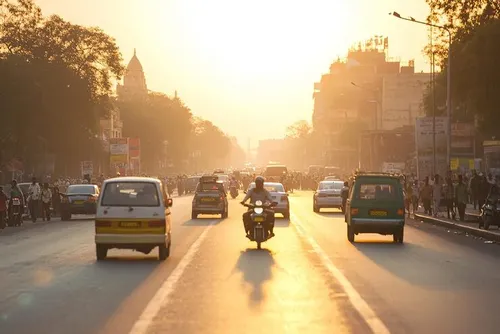

In [5]:
display(result["image"])

In [6]:
def get_test_summary(result):
    """
    Extract the important metrics from one test result.
    """

    analysis = result["analysis"]

    spatial_results = analysis["spatial_results"]

    high_count = sum(
        1
        for detection in spatial_results
        if detection["risk_level"] == "HIGH"
        and detection["inside_danger_zone"]
    )

    medium_count = sum(
        1
        for detection in spatial_results
        if detection["risk_level"] == "MEDIUM"
        and detection["inside_danger_zone"]
    )

    ego_lane_count = sum(
        1
        for detection in spatial_results
        if detection["inside_danger_zone"]
    )

    object_counts = analysis["object_counts"]

    return {
        "detections": len(result["detections"]),
        "vehicles": object_counts.get("vehicles", 0),
        "people": object_counts.get("people", 0),
        "bicycles": object_counts.get("bicycles", 0),
        "motorcycles": object_counts.get("motorcycles", 0),
        "high_risk": high_count,
        "medium_risk": medium_count,
        "ego_lane_objects": ego_lane_count
    }

In [7]:
baseline_summary = get_test_summary(result)

baseline_summary

{'detections': 50,
 'vehicles': 19,
 'people': 28,
 'bicycles': 0,
 'motorcycles': 3,
 'high_risk': 9,
 'medium_risk': 19,
 'ego_lane_objects': 28}

In [8]:
results = []

test_images = [
    "../images/road.jpg",
    "../images/test/road_01.jpg",
    "../images/test/road_02.jpg",
    "../images/test/road_03.jpg",
    "../images/test/road_04.jpg",
    "../images/test/road_05.jpg",
]

for image_path in test_images:

    result = test_image(image_path)

    summary = get_test_summary(result)

    summary["image"] = Path(image_path).name

    results.append(summary)

Image: ../images/road.jpg
Detections       : 50

Object counts:
  vehicles        : 19
  people          : 28
  bicycles        : 0
  motorcycles     : 3

Risk summary:
  High risk       : 9
  Medium risk     : 19
  Ego-lane objects: 28

Warnings:
  ⚠ HIGH: 9 pedestrians in ego-lane
  ⚠ HIGH: 16 cars in ego-lane
  ⚠ HIGH: Truck in ego-lane
  ⚠ HIGH: 2 motorcycles in ego-lane

Image: ../images/test/road_01.jpg
Detections       : 2

Object counts:
  vehicles        : 2
  people          : 0
  bicycles        : 0
  motorcycles     : 0

Risk summary:
  High risk       : 2
  Medium risk     : 0
  Ego-lane objects: 2

Warnings:
  ⚠ HIGH: Truck in ego-lane
  ⚠ HIGH: Car in ego-lane

Image: ../images/test/road_02.jpg
Detections       : 3

Object counts:
  vehicles        : 2
  people          : 1
  bicycles        : 0
  motorcycles     : 0

Risk summary:
  High risk       : 3
  Medium risk     : 0
  Ego-lane objects: 3

Warnings:
  ⚠ HIGH: Car in ego-lane
  ⚠ HIGH: Truck in ego-lane
  ⚠ HIGH: 

In [9]:
import pandas as pd

comparison = pd.DataFrame(results)

comparison = comparison[
    [
        "image",
        "detections",
        "vehicles",
        "people",
        "bicycles",
        "motorcycles",
        "high_risk",
        "medium_risk",
        "ego_lane_objects"
    ]
]

comparison

,image,detections,vehicles,people,bicycles,motorcycles,high_risk,medium_risk,ego_lane_objects
0,road.jpg,50,19,28,0,3,9,19,28
1,road_01.jpg,2,2,0,0,0,2,0,2
2,road_02.jpg,3,2,1,0,0,3,0,3
3,road_03.jpg,37,6,24,4,1,2,4,6
4,road_04.jpg,19,14,4,0,0,5,6,11
5,road_05.jpg,65,42,20,0,3,27,1,28


In [10]:
comparison.to_string(index=False)

'      image  detections  vehicles  people  bicycles  motorcycles  high_risk  medium_risk  ego_lane_objects\n   road.jpg          50        19      28         0            3          9           19                28\nroad_01.jpg           2         2       0         0            0          2            0                 2\nroad_02.jpg           3         2       1         0            0          3            0                 3\nroad_03.jpg          37         6      24         4            1          2            4                 6\nroad_04.jpg          19        14       4         0            0          5            6                11\nroad_05.jpg          65        42      20         0            3         27            1                28'

road_01.jpg


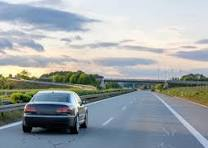

road_02.jpg


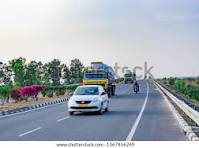

road_03.jpg


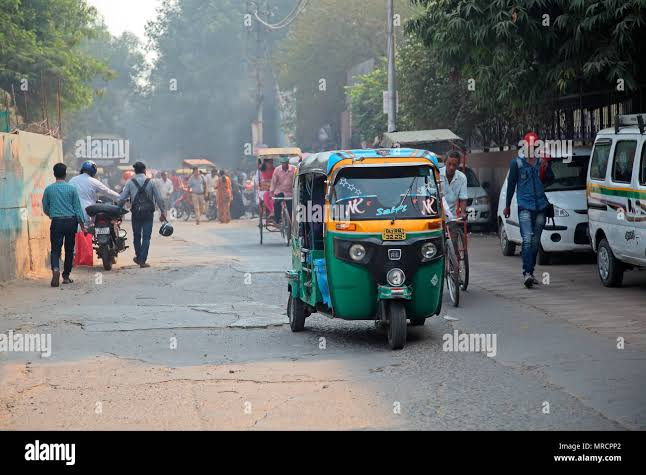

road_04.jpg


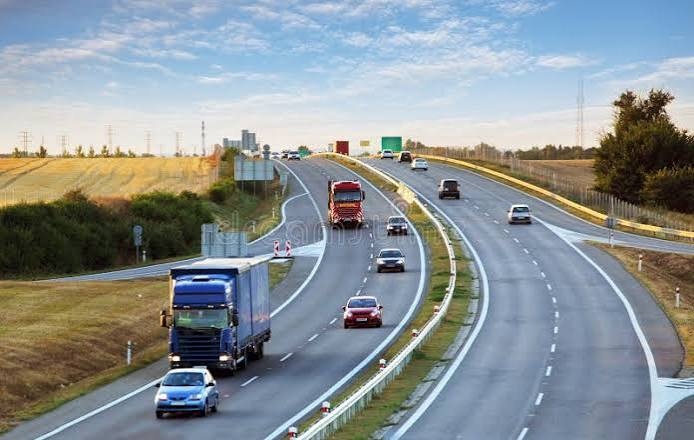

road_05.jpg


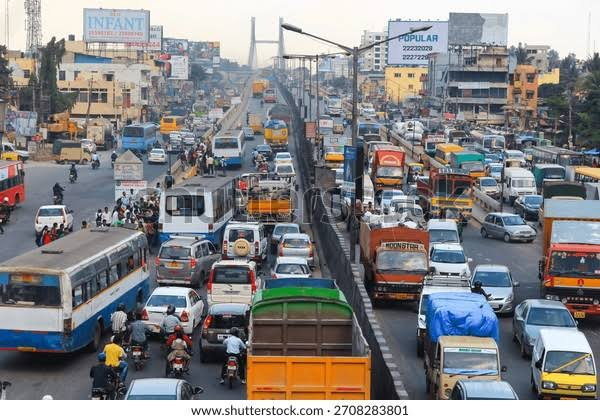

In [11]:
from IPython.display import display

test_paths = [
    "../images/test/road_01.jpg",
    "../images/test/road_02.jpg",
    "../images/test/road_03.jpg",
    "../images/test/road_04.jpg",
    "../images/test/road_05.jpg",
]

for path in test_paths:

    print("=" * 60)
    print(Path(path).name)
    print("=" * 60)

    test_image_data = Image.open(path).convert("RGB")

    display(test_image_data)

In [12]:
def inspect_risk(result):
    """
    Display the spatial and risk information
    for every detected object.
    """

    spatial_results = result["analysis"]["spatial_results"]

    rows = []

    for detection in spatial_results:

        rows.append({
            "label": detection["label"],
            "confidence": round(
                detection["score"],
                2
            ),
            "inside_ego_lane": detection[
                "inside_danger_zone"
            ],
            "proximity": detection[
                "proximity"
            ],
            "risk_score": round(
                detection["risk_score"],
                2
            ),
            "risk_level": detection[
                "risk_level"
            ]
        })

    return pd.DataFrame(rows)

In [13]:
result_05 = test_image(
    "../images/test/road_05.jpg"
)

Image: ../images/test/road_05.jpg
Detections       : 65

Object counts:
  vehicles        : 42
  people          : 20
  bicycles        : 0
  motorcycles     : 3

Risk summary:
  High risk       : 27
  Medium risk     : 1
  Ego-lane objects: 28

Warnings:
  ⚠ HIGH: 6 pedestrians in ego-lane
  ⚠ HIGH: 14 cars in ego-lane
  ⚠ HIGH: 2 trucks in ego-lane
  ⚠ HIGH: 3 motorcycles in ego-lane
  ⚠ HIGH: 3 buss in ego-lane



In [14]:
risk_05 = inspect_risk(result_05)

risk_05

,label,confidence,inside_ego_lane,proximity,risk_score,risk_level
0,person,0.89,False,far,0.53,MEDIUM
1,person,0.92,True,near,0.89,HIGH
2,bus,0.55,False,far,0.36,MEDIUM
3,car,0.89,True,near,0.79,HIGH
4,person,0.78,False,far,0.50,MEDIUM
...,...,...,...,...,...,...
60,car,0.91,True,medium,0.75,HIGH
61,person,0.99,True,near,0.90,HIGH
62,person,0.86,False,far,0.52,MEDIUM
63,bus,0.99,True,near,0.79,HIGH


In [15]:
risk_05.sort_values(
    "risk_score",
    ascending=False
)

,label,confidence,inside_ego_lane,proximity,risk_score,risk_level
61,person,0.99,True,near,0.90,HIGH
49,motorcycle,0.95,True,near,0.89,HIGH
1,person,0.92,True,near,0.89,HIGH
52,person,0.95,True,near,0.89,HIGH
34,person,0.97,True,near,0.88,HIGH
...,...,...,...,...,...,...
8,truck,0.63,False,far,0.37,MEDIUM
28,bus,0.58,False,far,0.36,MEDIUM
2,bus,0.55,False,far,0.36,MEDIUM
12,bus,0.52,False,far,0.36,MEDIUM


In [16]:
risk_05[
    risk_05["inside_ego_lane"] == True
]

,label,confidence,inside_ego_lane,proximity,risk_score,risk_level
1,person,0.92,True,near,0.89,HIGH
3,car,0.89,True,near,0.79,HIGH
5,truck,0.90,True,near,0.81,HIGH
11,car,0.78,True,near,0.79,HIGH
15,truck,0.76,True,near,0.75,HIGH
17,car,0.99,True,near,0.79,HIGH
19,car,0.93,True,near,0.79,HIGH
20,motorcycle,0.82,True,near,0.87,HIGH
26,person,0.79,True,near,0.86,HIGH
29,car,0.51,True,near,0.72,HIGH


In [17]:
result_03 = test_image(
    "../images/test/road_03.jpg"
)

risk_03 = inspect_risk(result_03)

risk_03.sort_values(
    "risk_score",
    ascending=False
)

Image: ../images/test/road_03.jpg
Detections       : 37

Object counts:
  vehicles        : 6
  people          : 24
  bicycles        : 4
  motorcycles     : 1

Risk summary:
  High risk       : 2
  Medium risk     : 4
  Ego-lane objects: 6

Warnings:
  ⚠ HIGH: 3 bicycles in ego-lane
  ⚠ MEDIUM: 2 pedestrians in ego-lane
  ⚠ HIGH: Truck in ego-lane



,label,confidence,inside_ego_lane,proximity,risk_score,risk_level
4,bicycle,0.99,True,medium,0.87,HIGH
35,person,1.00,True,far,0.84,MEDIUM
36,bicycle,0.94,True,far,0.83,MEDIUM
15,bicycle,0.84,True,far,0.81,MEDIUM
19,person,0.86,True,far,0.81,MEDIUM
26,truck,0.89,True,near,0.80,HIGH
5,person,1.00,False,medium,0.57,MEDIUM
16,person,1.00,False,medium,0.57,MEDIUM
21,person,1.00,False,medium,0.56,MEDIUM
28,person,0.99,False,medium,0.56,MEDIUM


In [18]:
risk_05[
    risk_05["inside_ego_lane"] == True
]["label"].value_counts()

label
car           14
person         6
motorcycle     3
bus            3
truck          2
Name: count, dtype: int64

In [19]:
risk_05[
    risk_05["inside_ego_lane"] == True
]["proximity"].value_counts()

proximity
near      20
medium     7
far        1
Name: count, dtype: int64

In [20]:
risk_05[
    risk_05["inside_ego_lane"] == True
]["risk_level"].value_counts()

risk_level
HIGH      27
MEDIUM     1
Name: count, dtype: int64

In [21]:
import io
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from PIL import Image

In [22]:
def create_annotated_image(
        image,
        spatial_results,
        danger_zone
):
    """
    Create an annotated ADAS image and return it as a PIL image.

    This function is designed for UI output.
    """

    width = image.width
    height = image.height

    # Convert normalized danger-zone coordinates
    zone_points = [
        (
            x * width,
            y * height
        )
        for x, y in danger_zone
    ]

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )

    ax.imshow(image)

    # Draw ego-lane
    polygon = Polygon(
        zone_points,
        closed=True,
        fill=False,
        linewidth=3
    )

    ax.add_patch(polygon)

    # Keep relevant detections
    relevant = [
        detection
        for detection in spatial_results
        if detection["risk_level"] in {
            "MEDIUM",
            "HIGH"
        }
    ]

    # Highest risk first
    relevant.sort(
        key=lambda detection: detection["risk_score"],
        reverse=True
    )

    # Draw detections
    for index, detection in enumerate(relevant):

        label = detection["label"]
        confidence = detection["score"]

        xmin, ymin, xmax, ymax = detection["box"]

        center_x, center_y = detection["center"]

        bottom_x, bottom_y = detection["bottom_center"]

        risk_level = detection["risk_level"]
        risk_score = detection["risk_score"]

        proximity = detection["proximity"]

        linewidth = 4 if risk_level == "HIGH" else 2

        rectangle = Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=linewidth
        )

        ax.add_patch(rectangle)

        # Center point
        ax.scatter(
            center_x,
            center_y,
            s=30
        )

        # Bottom-center point
        ax.scatter(
            bottom_x,
            bottom_y,
            s=45
        )

        # Label top 5 detections
        if index < 5:

            text = (
                f"{label} {confidence:.2f}\n"
                f"{risk_level} | {proximity.upper()}\n"
                f"risk={risk_score:.2f}"
            )

            ax.text(
                xmin,
                max(5, ymin - 5),
                text,
                fontsize=9,
                verticalalignment="bottom",
                backgroundcolor="white"
            )

    # Summary
    high_count = sum(
        1
        for detection in spatial_results
        if detection["risk_level"] == "HIGH"
        and detection["inside_danger_zone"]
    )

    medium_count = sum(
        1
        for detection in spatial_results
        if detection["risk_level"] == "MEDIUM"
        and detection["inside_danger_zone"]
    )

    ego_lane_count = sum(
        1
        for detection in spatial_results
        if detection["inside_danger_zone"]
    )

    summary = (
        f"ADAS SUMMARY | "
        f"HIGH: {high_count} | "
        f"MEDIUM: {medium_count} | "
        f"EGO-LANE OBJECTS: {ego_lane_count}"
    )

    ax.text(
        0.02,
        0.97,
        summary,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        backgroundcolor="white"
    )

    ax.set_title(
        "Mini ADAS — Spatial Risk Analysis"
    )

    ax.axis("off")

    plt.tight_layout()

    # -----------------------------------------------
    # Convert Matplotlib figure → PIL image
    # -----------------------------------------------

    buffer = io.BytesIO()

    fig.savefig(
        buffer,
        format="png",
        bbox_inches="tight"
    )

    plt.close(fig)

    buffer.seek(0)

    annotated_image = Image.open(buffer).convert("RGB")

    return annotated_image

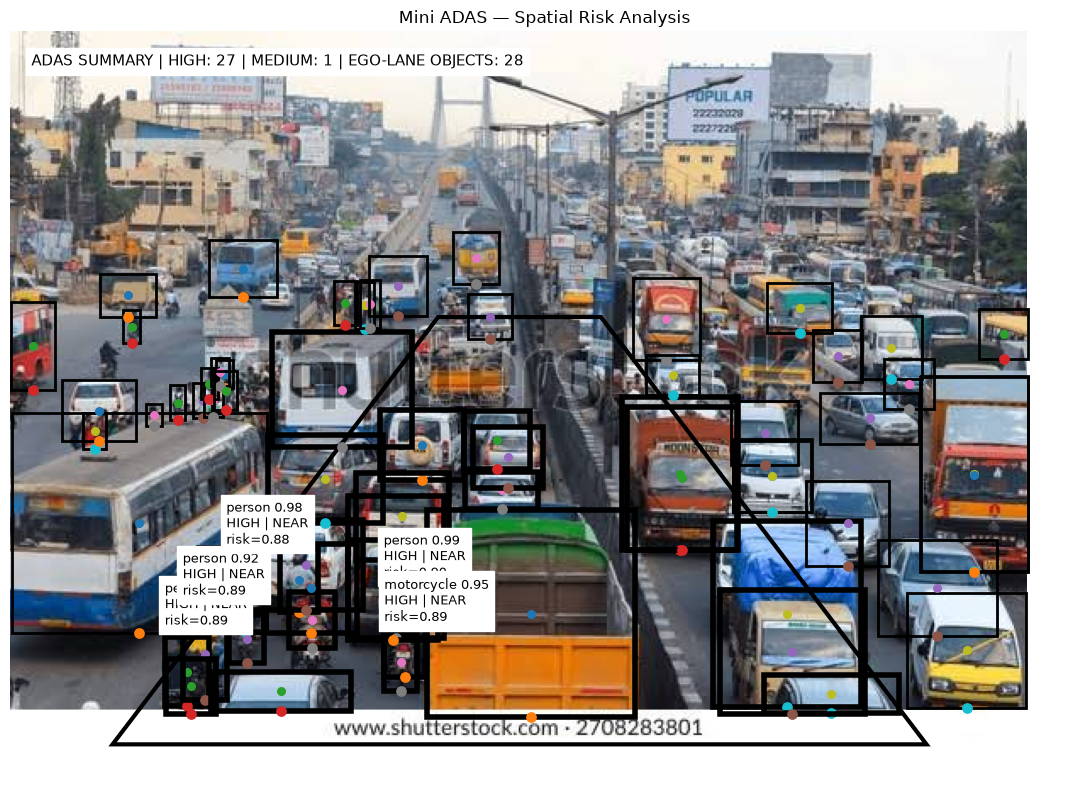

In [23]:
annotated_05 = create_annotated_image(
    result_05["image"],
    result_05["analysis"]["spatial_results"],
    result_05["analyzer"].danger_zone
)

display(annotated_05)

In [24]:
result_03 = test_image(
    "../images/test/road_03.jpg"
)

risk_03 = inspect_risk(result_03)

Image: ../images/test/road_03.jpg
Detections       : 37

Object counts:
  vehicles        : 6
  people          : 24
  bicycles        : 4
  motorcycles     : 1

Risk summary:
  High risk       : 2
  Medium risk     : 4
  Ego-lane objects: 6

Warnings:
  ⚠ HIGH: 3 bicycles in ego-lane
  ⚠ MEDIUM: 2 pedestrians in ego-lane
  ⚠ HIGH: Truck in ego-lane



In [25]:
risk_03[
    risk_03["inside_ego_lane"] == True
]

,label,confidence,inside_ego_lane,proximity,risk_score,risk_level
4,bicycle,0.99,True,medium,0.87,HIGH
15,bicycle,0.84,True,far,0.81,MEDIUM
19,person,0.86,True,far,0.81,MEDIUM
26,truck,0.89,True,near,0.80,HIGH
35,person,1.00,True,far,0.84,MEDIUM
36,bicycle,0.94,True,far,0.83,MEDIUM


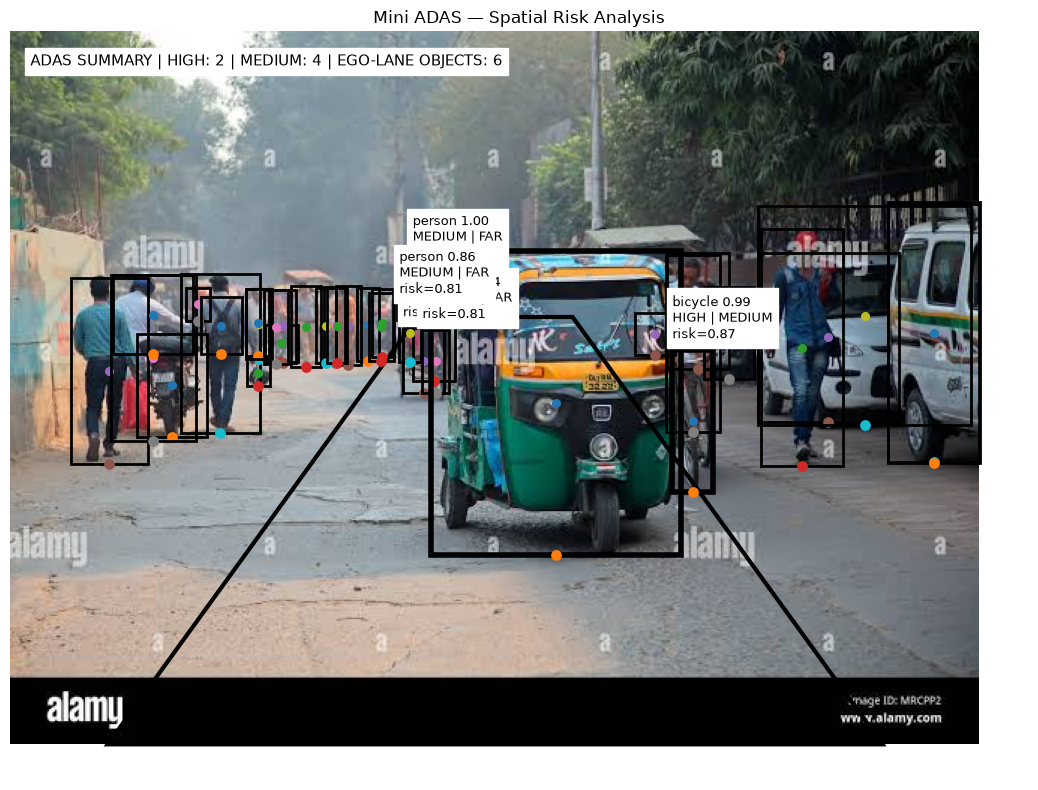

In [26]:
annotated_03 = create_annotated_image(
    result_03["image"],
    result_03["analysis"]["spatial_results"],
    result_03["analyzer"].danger_zone
)

display(annotated_03)

In [27]:
for filename in [
    "road_01.jpg",
    "road_02.jpg",
    "road_04.jpg"
]:
    result = test_image(
        f"../images/test/{filename}"
    )

    risk = inspect_risk(result)

    print("\nEgo-lane objects:")
    display(
        risk[
            risk["inside_ego_lane"] == True
        ]
    )

Image: ../images/test/road_01.jpg
Detections       : 2

Object counts:
  vehicles        : 2
  people          : 0
  bicycles        : 0
  motorcycles     : 0

Risk summary:
  High risk       : 2
  Medium risk     : 0
  Ego-lane objects: 2

Warnings:
  ⚠ HIGH: Truck in ego-lane
  ⚠ HIGH: Car in ego-lane


Ego-lane objects:


,label,confidence,inside_ego_lane,proximity,risk_score,risk_level
0,truck,0.89,True,near,0.81,HIGH
1,car,0.99,True,near,0.82,HIGH


Image: ../images/test/road_02.jpg
Detections       : 3

Object counts:
  vehicles        : 2
  people          : 1
  bicycles        : 0
  motorcycles     : 0

Risk summary:
  High risk       : 3
  Medium risk     : 0
  Ego-lane objects: 3

Warnings:
  ⚠ HIGH: Car in ego-lane
  ⚠ HIGH: Truck in ego-lane
  ⚠ HIGH: Pedestrian in ego-lane


Ego-lane objects:


,label,confidence,inside_ego_lane,proximity,risk_score,risk_level
0,car,1.00,True,near,0.80,HIGH
1,truck,0.98,True,medium,0.78,HIGH
2,person,0.86,True,medium,0.84,HIGH


Image: ../images/test/road_04.jpg
Detections       : 19

Object counts:
  vehicles        : 14
  people          : 4
  bicycles        : 0
  motorcycles     : 0

Risk summary:
  High risk       : 5
  Medium risk     : 6
  Ego-lane objects: 11

Warnings:
  ⚠ HIGH: 4 cars in ego-lane
  ⚠ HIGH: 4 pedestrians in ego-lane
  ⚠ MEDIUM: Bus in ego-lane
  ⚠ HIGH: Truck in ego-lane


Ego-lane objects:


,label,confidence,inside_ego_lane,proximity,risk_score,risk_level
1,car,1.00,True,near,0.81,HIGH
3,person,0.81,True,far,0.81,MEDIUM
4,person,0.60,True,near,0.82,HIGH
5,fire hydrant,0.54,True,near,0.68,HIGH
6,car,1.00,True,far,0.76,MEDIUM
8,person,0.52,True,far,0.77,MEDIUM
10,bus,1.00,True,far,0.75,MEDIUM
11,person,0.50,True,far,0.77,MEDIUM
13,truck,1.00,True,near,0.81,HIGH
16,car,0.99,True,far,0.74,MEDIUM


In [28]:
result_04 = test_image(
    "../images/test/road_04.jpg"
)

Image: ../images/test/road_04.jpg
Detections       : 19

Object counts:
  vehicles        : 14
  people          : 4
  bicycles        : 0
  motorcycles     : 0

Risk summary:
  High risk       : 5
  Medium risk     : 6
  Ego-lane objects: 11

Warnings:
  ⚠ HIGH: 4 cars in ego-lane
  ⚠ HIGH: 4 pedestrians in ego-lane
  ⚠ MEDIUM: Bus in ego-lane
  ⚠ HIGH: Truck in ego-lane



In [29]:
results = []

test_images = [
    "../images/road.jpg",
    "../images/test/road_01.jpg",
    "../images/test/road_02.jpg",
    "../images/test/road_03.jpg",
    "../images/test/road_04.jpg",
    "../images/test/road_05.jpg",
]

for image_path in test_images:

    result = test_image(image_path)

    summary = get_test_summary(result)

    summary["image"] = Path(image_path).name

    results.append(summary)

Image: ../images/road.jpg
Detections       : 50

Object counts:
  vehicles        : 19
  people          : 28
  bicycles        : 0
  motorcycles     : 3

Risk summary:
  High risk       : 9
  Medium risk     : 19
  Ego-lane objects: 28

Warnings:
  ⚠ HIGH: 9 pedestrians in ego-lane
  ⚠ HIGH: 16 cars in ego-lane
  ⚠ HIGH: Truck in ego-lane
  ⚠ HIGH: 2 motorcycles in ego-lane

Image: ../images/test/road_01.jpg
Detections       : 2

Object counts:
  vehicles        : 2
  people          : 0
  bicycles        : 0
  motorcycles     : 0

Risk summary:
  High risk       : 2
  Medium risk     : 0
  Ego-lane objects: 2

Warnings:
  ⚠ HIGH: Truck in ego-lane
  ⚠ HIGH: Car in ego-lane

Image: ../images/test/road_02.jpg
Detections       : 3

Object counts:
  vehicles        : 2
  people          : 1
  bicycles        : 0
  motorcycles     : 0

Risk summary:
  High risk       : 3
  Medium risk     : 0
  Ego-lane objects: 3

Warnings:
  ⚠ HIGH: Car in ego-lane
  ⚠ HIGH: Truck in ego-lane
  ⚠ HIGH: 

In [30]:
comparison = pd.DataFrame(results)

comparison = comparison[
    [
        "image",
        "detections",
        "vehicles",
        "people",
        "bicycles",
        "motorcycles",
        "high_risk",
        "medium_risk",
        "ego_lane_objects"
    ]
]

comparison

,image,detections,vehicles,people,bicycles,motorcycles,high_risk,medium_risk,ego_lane_objects
0,road.jpg,50,19,28,0,3,9,19,28
1,road_01.jpg,2,2,0,0,0,2,0,2
2,road_02.jpg,3,2,1,0,0,3,0,3
3,road_03.jpg,37,6,24,4,1,2,4,6
4,road_04.jpg,19,14,4,0,0,5,6,11
5,road_05.jpg,65,42,20,0,3,27,1,28
